In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime
import IPython.display as display
from PIL import Image
import io
import time

In [2]:
video_path_train = r"C:\Users\PC-LAB1\img_processing_lab\videos\dhaka_traffic.mp4"
video_path_test = r"C:\Users\PC-LAB1\img_processing_lab\videos\british_highway_traffic.mp4"

In [3]:
def run_pipeline(
    input_video_path, output_video_path, strategy="hybrid", config=None
):
    """Executes a computer vision video processing pipeline, overlays live metrics,

    logs performance data, and saves the output to disk.
    """
    if config is None:
        config = {}

    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Error: Unable to open input video at '{input_video_path}'")
        return None

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    if video_fps == 0 or np.isnan(video_fps):
        video_fps = 25.0

    orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Dimensions for output writing
    if strategy.lower() == "hybrid":
        target_w, target_h = config.get("target_size", (640, 360))
    else:
        target_w, target_h = orig_w, orig_h

    # Initialize VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(
        output_video_path, fourcc, video_fps, (target_w, target_h)
    )

    # Initialize MOG2 Subtractor based on pipeline type
    if strategy.lower() == "hybrid":
        history = config.get("history", 300)
        var_thresh = config.get("var_threshold", 50)
    else:  # Complex
        history = config.get("history", 200)
        var_thresh = config.get("var_threshold", 50)

    backSub = cv2.createBackgroundSubtractorMOG2(
        history=history, varThreshold=var_thresh, detectShadows=True
    )

    # Morphological kernels
    k_small = np.ones((3, 3), np.uint8)
    k_med = np.ones((5, 5), np.uint8)
    k_large = np.ones((7, 7), np.uint8)

    # Performance logging arrays
    frame_indices = []
    moving_objects_history = []
    processing_fps_history = []

    frame_count = 0
    start_total_time = time.perf_counter()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        t_frame_start = time.perf_counter()

        # -------------------------------------------------------------
        # 1. PIPELINE EXECUTION
        # -------------------------------------------------------------
        if strategy.lower() == "hybrid":
            resized = cv2.resize(frame, (target_w, target_h))
            fg_mask = backSub.apply(resized)
            _, binary = cv2.threshold(fg_mask, 250, 255, cv2.THRESH_BINARY)
            median = cv2.medianBlur(binary, 5)
            clean = cv2.morphologyEx(median, cv2.MORPH_CLOSE, k_med)
            clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, k_small)
            display_frame = resized.copy()
            min_area, max_area = config.get("area_range", (250, 12000))

        else:  # Complex Strategy
            fg_mask = backSub.apply(frame)
            _, binary = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
            median = cv2.medianBlur(binary, 9)
            clean = cv2.morphologyEx(
                median, cv2.MORPH_CLOSE, k_large, iterations=2
            )
            display_frame = frame.copy()
            min_area = config.get("min_area", 500)
            max_area = config.get("max_area", 50000)

        # -------------------------------------------------------------
        # 2. CONTOUR DETECTION & FILTERING
        # -------------------------------------------------------------
        contours, _ = cv2.findContours(
            clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        detected_objects = 0

        # Spike guard check (Hybrid uses < 30)
        spike_guard_limit = (
            30 if strategy.lower() == "hybrid" else float("inf")
        )

        if len(contours) < spike_guard_limit:
            for cnt in contours:
                area = cv2.contourArea(cnt)
                x, y, w, h = cv2.boundingRect(cnt)
                aspect_ratio = float(w) / h if h > 0 else 0

                if strategy.lower() == "hybrid":
                    if (
                        (min_area <= area <= max_area)
                        and (20 <= w <= 220)
                        and (20 <= h <= 220)
                    ):
                        if 0.35 <= aspect_ratio <= 2.8:
                            detected_objects += 1
                            cv2.rectangle(
                                display_frame,
                                (x, y),
                                (x + w, y + h),
                                (0, 255, 0),
                                2,
                            )
                else:  # Complex
                    if min_area <= area <= max_area:
                        detected_objects += 1
                        cv2.rectangle(
                            display_frame,
                            (x, y),
                            (x + w, y + h),
                            (0, 255, 0),
                            2,
                        )

        # Calculate per-frame processing FPS
        t_frame_end = time.perf_counter()
        frame_proc_time = t_frame_end - t_frame_start
        proc_fps = 1.0 / frame_proc_time if frame_proc_time > 0 else 0.0

        # Log metrics
        frame_indices.append(frame_count)
        moving_objects_history.append(detected_objects)
        processing_fps_history.append(proc_fps)

        # -------------------------------------------------------------
        # 3. METRICS OVERLAY DISPLAY
        # -------------------------------------------------------------
        overlay = display_frame.copy()
        cv2.rectangle(overlay, (10, 10), (280, 130), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.6, display_frame, 0.4, 0, display_frame)

        cv2.putText(
            display_frame,
            f"Video FPS:      {video_fps:.1f}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        cv2.putText(
            display_frame,
            f"Processing FPS: {proc_fps:.1f}",
            (20, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )
        cv2.putText(
            display_frame,
            f"Frame:          {frame_count}",
            (20, 85),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        cv2.putText(
            display_frame,
            f"Moving Objects: {detected_objects}",
            (20, 110),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 255),
            2,
            cv2.LINE_AA,
        )

        out.write(display_frame)

    cap.release()
    out.release()

    total_runtime = time.perf_counter() - start_total_time
    avg_proc_fps = frame_count / total_runtime if total_runtime > 0 else 0

    print(
        f"[{strategy.upper()} COMPLETE] Processed {frame_count} frames in {total_runtime:.2f}s | Avg FPS: {avg_proc_fps:.2f}"
    )

    df_metrics = pd.DataFrame(
        {
            "Frame": frame_indices,
            "Moving_Objects": moving_objects_history,
            "Processing_FPS": processing_fps_history,
        }
    )

    return df_metrics

In [4]:
# Create output directory for processed videos
os.makedirs(r"C:\Users\PC-LAB1\img_processing_lab\output", exist_ok=True)

out_train_hybrid = (
    r"C:\Users\PC-LAB1\img_processing_lab\output\dhaka_hybrid.mp4"
)
out_train_complex = (
    r"C:\Users\PC-LAB1\img_processing_lab\output\dhaka_complex.mp4"
)

# 1. Run Hybrid Pipeline on Training Data
config_hybrid = {
    "history": 300,
    "var_threshold": 50,
    "target_size": (640, 360),
    "area_range": (250, 12000),
}
df_train_hybrid = run_pipeline(
    video_path_train,
    out_train_hybrid,
    strategy="hybrid",
    config=config_hybrid,
)

# 2. Run Complex Pipeline on Training Data
config_complex = {
    "history": 200,
    "var_threshold": 50,
    "min_area": 500,
    "max_area": 50000,
}
df_train_complex = run_pipeline(
    video_path_train,
    out_train_complex,
    strategy="complex",
    config=config_complex,
)

[HYBRID COMPLETE] Processed 3794 frames in 26.07s | Avg FPS: 145.56
[COMPLEX COMPLETE] Processed 3794 frames in 48.66s | Avg FPS: 77.97


In [5]:
out_test_hybrid = (
    r"C:\Users\PC-LAB1\img_processing_lab\output\highway_hybrid.mp4"
)
out_test_complex = (
    r"C:\Users\PC-LAB1\img_processing_lab\output\highway_complex.mp4"
)

# Run pipelines on unseen test video
df_test_hybrid = run_pipeline(
    video_path_test, out_test_hybrid, strategy="hybrid", config=config_hybrid
)

df_test_complex = run_pipeline(
    video_path_test, out_test_complex, strategy="complex", config=config_complex
)

[HYBRID COMPLETE] Processed 1549 frames in 21.54s | Avg FPS: 71.90
[COMPLEX COMPLETE] Processed 1549 frames in 123.33s | Avg FPS: 12.56


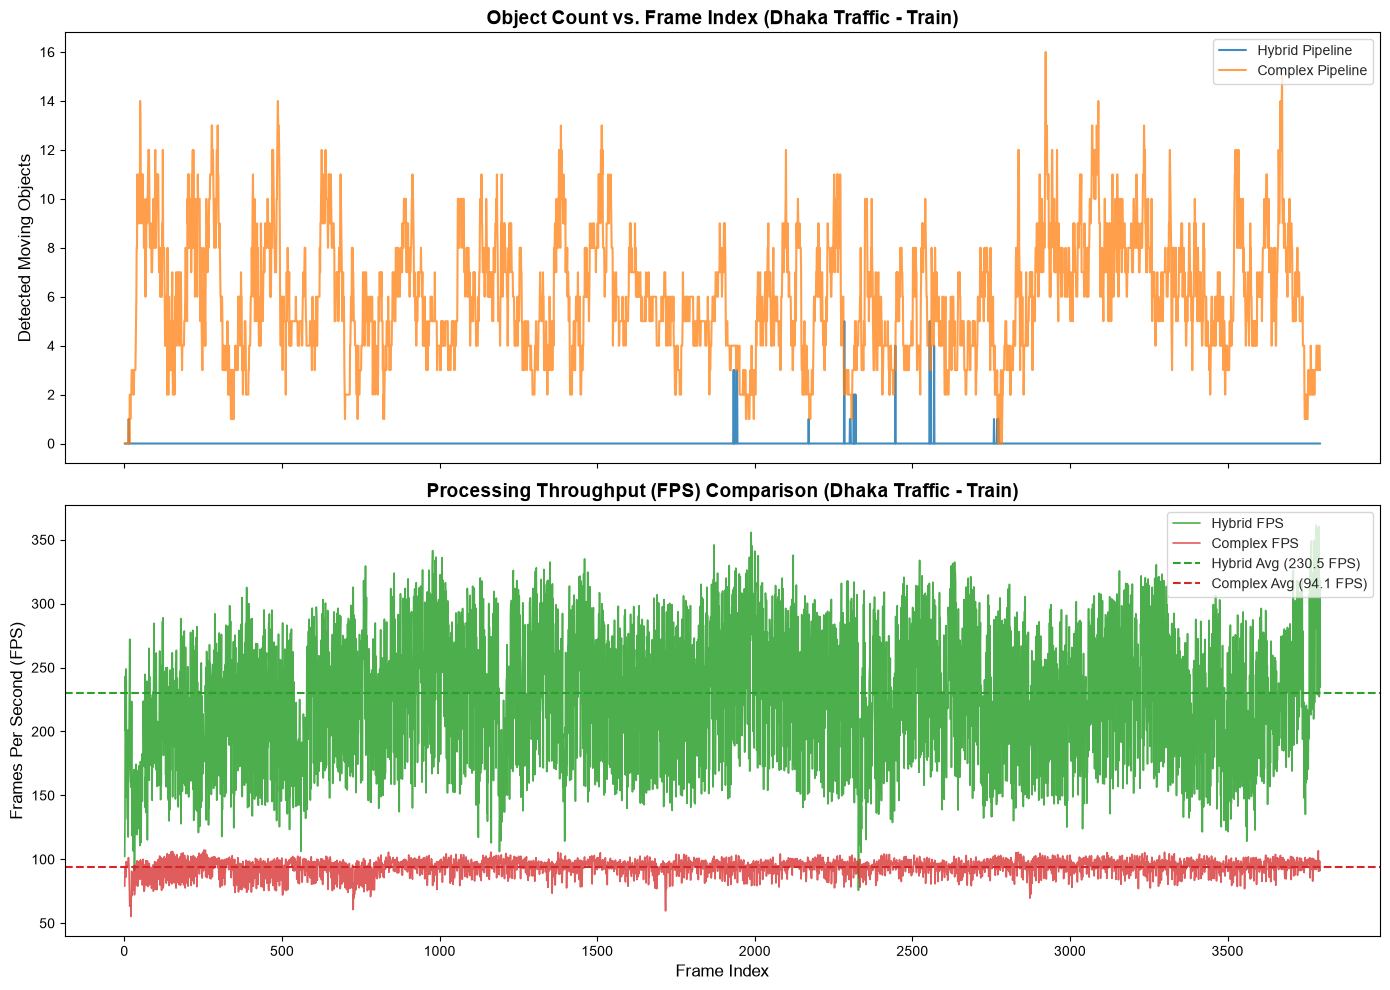

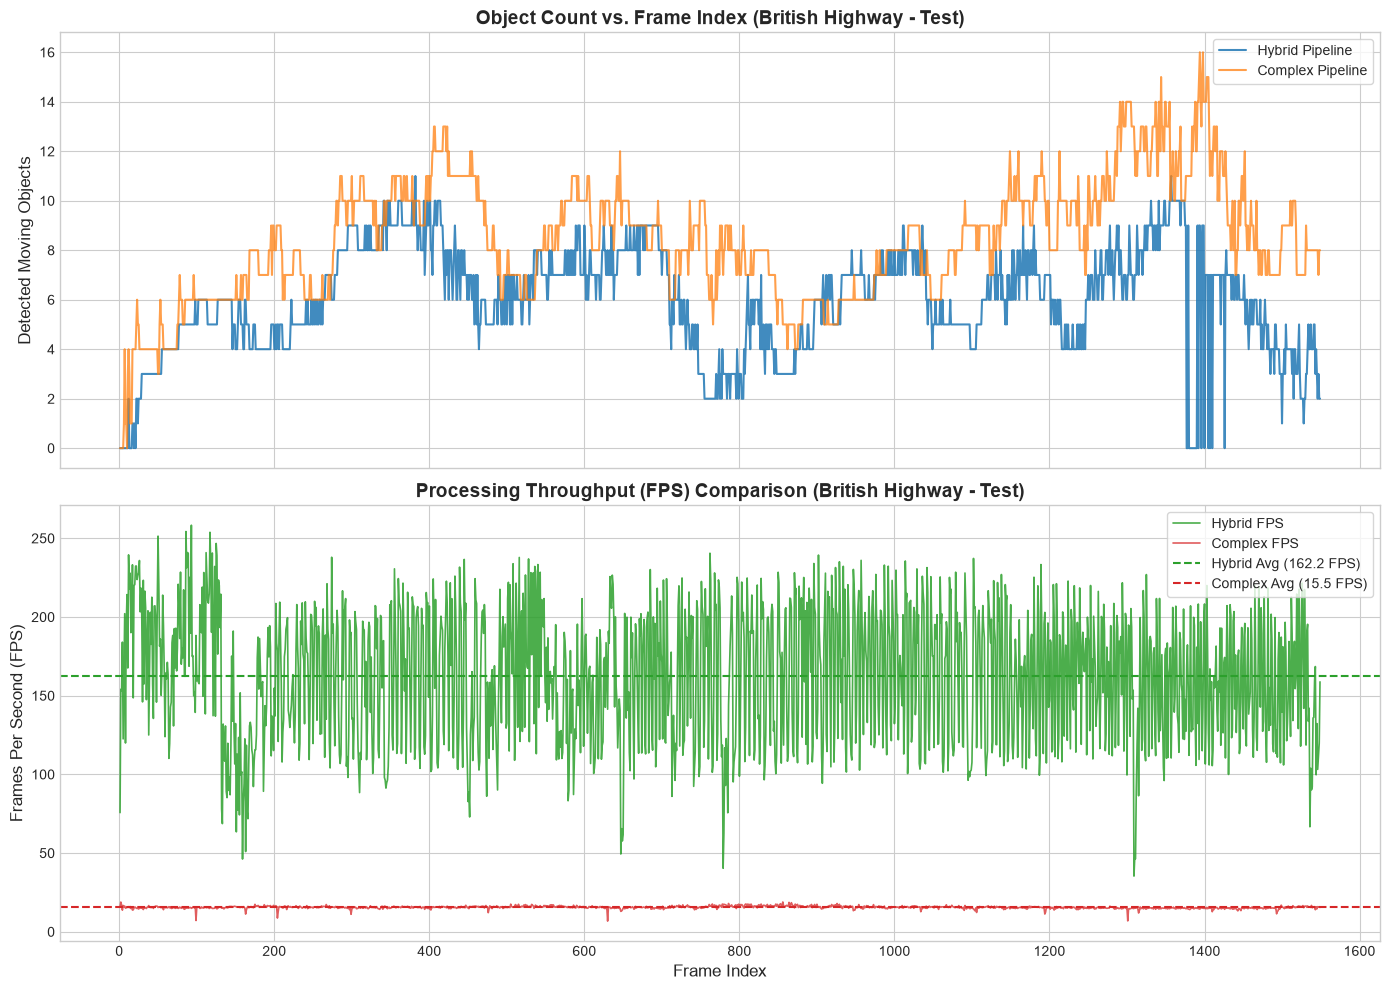

In [6]:
def plot_pipeline_comparisons(df_hybrid, df_complex, dataset_title="Traffic"):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

    # Plot 1: Object Count vs Frame / Time
    axes[0].plot(
        df_hybrid["Frame"],
        df_hybrid["Moving_Objects"],
        label="Hybrid Pipeline",
        color="#1f77b4",
        alpha=0.85,
        linewidth=1.5,
    )
    axes[0].plot(
        df_complex["Frame"],
        df_complex["Moving_Objects"],
        label="Complex Pipeline",
        color="#ff7f0e",
        alpha=0.75,
        linewidth=1.5,
    )
    axes[0].set_title(
        f"Object Count vs. Frame Index ({dataset_title})",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].set_ylabel("Detected Moving Objects", fontsize=12)
    axes[0].legend(loc="upper right", frameon=True)

    # Plot 2: Processing FPS Comparison
    axes[1].plot(
        df_hybrid["Frame"],
        df_hybrid["Processing_FPS"],
        label="Hybrid FPS",
        color="#2ca02c",
        alpha=0.85,
        linewidth=1.2,
    )
    axes[1].plot(
        df_complex["Frame"],
        df_complex["Processing_FPS"],
        label="Complex FPS",
        color="#d62728",
        alpha=0.75,
        linewidth=1.2,
    )
    axes[1].axhline(
        y=df_hybrid["Processing_FPS"].mean(),
        color="#2ca02c",
        linestyle="--",
        label=f"Hybrid Avg ({df_hybrid['Processing_FPS'].mean():.1f} FPS)",
    )
    axes[1].axhline(
        y=df_complex["Processing_FPS"].mean(),
        color="#d62728",
        linestyle="--",
        label=f"Complex Avg ({df_complex['Processing_FPS'].mean():.1f} FPS)",
    )
    axes[1].set_title(
        f"Processing Throughput (FPS) Comparison ({dataset_title})",
        fontsize=14,
        fontweight="bold",
    )
    axes[1].set_xlabel("Frame Index", fontsize=12)
    axes[1].set_ylabel("Frames Per Second (FPS)", fontsize=12)
    axes[1].legend(loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()


# Render plots for training dataset comparison
plot_pipeline_comparisons(
    df_train_hybrid, df_train_complex, dataset_title="Dhaka Traffic - Train"
)

# Render plots for generalization test comparison
plot_pipeline_comparisons(
    df_test_hybrid, df_test_complex, dataset_title="British Highway - Test"
)

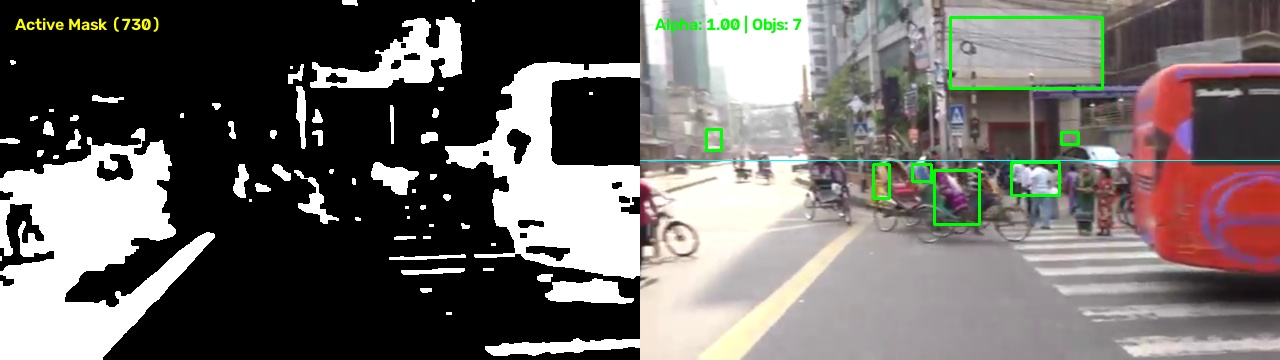

Streaming Fixed Optical Flow Pipeline...
Frame 30 | Applied Shift X: -1.10px, Y: -0.22px
Frame 60 | Applied Shift X: 2.52px, Y: -2.48px
Frame 90 | Applied Shift X: -3.39px, Y: 0.01px
Frame 120 | Applied Shift X: -11.81px, Y: 0.78px
Frame 150 | Applied Shift X: -8.69px, Y: 2.22px
Frame 180 | Applied Shift X: 1.87px, Y: 0.76px
Frame 210 | Applied Shift X: 14.12px, Y: -0.86px
Frame 240 | Applied Shift X: 13.95px, Y: -1.74px
Frame 270 | Applied Shift X: 0.61px, Y: -0.48px
Frame 300 | Applied Shift X: 7.66px, Y: 0.85px
Frame 330 | Applied Shift X: 1.55px, Y: -0.65px
Frame 360 | Applied Shift X: 2.41px, Y: -0.21px
Frame 390 | Applied Shift X: 1.54px, Y: -0.15px
Frame 420 | Applied Shift X: 11.48px, Y: -1.85px
Frame 450 | Applied Shift X: -5.03px, Y: 0.37px
Frame 480 | Applied Shift X: -1.51px, Y: 0.00px
Frame 510 | Applied Shift X: 0.05px, Y: -0.01px
Frame 540 | Applied Shift X: -1.33px, Y: 0.13px
Frame 570 | Applied Shift X: 2.01px, Y: -0.28px
Frame 600 | Applied Shift X: 12.02px, Y: -0.32p

In [30]:
# ==============================================================================
# HYBRID PIPELINE - OPTICAL FLOW (BUG-FIXED & VERIFIED)
# ==============================================================================

HYBRID_CONFIG = {
    # MOG2 & Object Filtering Parameters
    "history": 200,
    "varThreshold": 32,
    "shadow_thresh": 250,
    "median_kernel": 5,
    "target_size": (640, 360),
    "min_area": 120,
    "max_area": 15000,
    "min_w_h": 10,
    "max_w_h": 220,
    "aspect_ratio_range": (0.3, 3.0),
    # --------------------------------------------------------------------------
    # OPTICAL FLOW TUNABLE CONTROLS
    # --------------------------------------------------------------------------
    "optflow_roi_height": 160,  # Top 160px for tracking (buildings/skyline)
    "blend_alpha": 1.0,  # Softening Factor (0.0 = Off, 1.0 = Full Flow)
    "ema_decay": 0.2,  # Matrix smoothing across frames
    "dof_mode": "translation",  # 'translation' or 'partial_affine'
    "max_pixel_shift": 50.0,  # Hard clamp threshold for extreme spikes
}

cap = cv2.VideoCapture(video_path_train)

backSub_fixed = cv2.createBackgroundSubtractorMOG2(
    history=HYBRID_CONFIG["history"],
    varThreshold=HYBRID_CONFIG["varThreshold"],
    detectShadows=True,
)

k_small = np.ones((3, 3), np.uint8)
k_med = np.ones((5, 5), np.uint8)

# Mask for Optical Flow ONLY (Top half of screen)
optflow_mask = np.zeros((360, 640), dtype=np.uint8)
optflow_mask[0 : HYBRID_CONFIG["optflow_roi_height"], :] = 255

ret, prev_frame = cap.read()
if ret:
    prev_resized = cv2.resize(prev_frame, HYBRID_CONFIG["target_size"])
    prev_gray = cv2.cvtColor(prev_resized, cv2.COLOR_BGR2GRAY)

display_handle = display.display(None, display_id=True)
frame_idx = 1

# Base Identity Matrix (Zero transformation baseline)
I_matrix = np.float32([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
smooth_matrix = I_matrix.copy()

print("Streaming Fixed Optical Flow Pipeline...")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        curr_resized = cv2.resize(frame, HYBRID_CONFIG["target_size"])
        curr_gray = cv2.cvtColor(curr_resized, cv2.COLOR_BGR2GRAY)

        # 1. Feature Tracking strictly within upper static ROI
        prev_pts = cv2.goodFeaturesToTrack(
            prev_gray,
            maxCorners=200,
            qualityLevel=0.01,
            minDistance=10,
            mask=optflow_mask,
        )

        raw_matrix = I_matrix.copy()

        if prev_pts is not None and len(prev_pts) > 8:
            curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(
                prev_gray, curr_gray, prev_pts, None
            )

            # --- FIX 1: Proper 2D Status Boolean Masking ---
            valid = status.ravel() == 1
            if np.sum(valid) > 8:
                # --- FIX 2: Squeeze/Reshape arrays to (N, 2) ---
                good_prev = prev_pts[valid].reshape(-1, 2)
                good_curr = curr_pts[valid].reshape(-1, 2)

                if HYBRID_CONFIG["dof_mode"] == "translation":
                    movement = good_curr - good_prev
                    dx = np.median(movement[:, 0])
                    dy = np.median(movement[:, 1])

                    # Clamp movement spikes
                    dx = np.clip(
                        dx,
                        -HYBRID_CONFIG["max_pixel_shift"],
                        HYBRID_CONFIG["max_pixel_shift"],
                    )
                    dy = np.clip(
                        dy,
                        -HYBRID_CONFIG["max_pixel_shift"],
                        HYBRID_CONFIG["max_pixel_shift"],
                    )

                    raw_matrix = np.float32([[1.0, 0.0, -dx], [0.0, 1.0, -dy]])

                elif HYBRID_CONFIG["dof_mode"] == "partial_affine":
                    # --- FIX 3: Matrix Estimation with Squeezed Coordinates ---
                    M_est, inliers = cv2.estimateAffinePartial2D(
                        good_curr,
                        good_prev,
                        method=cv2.RANSAC,
                        ransacReprojThreshold=3.0,
                    )

                    if M_est is not None:
                        # Verify shift isn't insane before using
                        if (
                            abs(M_est[0, 2]) < HYBRID_CONFIG["max_pixel_shift"]
                            and abs(M_est[1, 2])
                            < HYBRID_CONFIG["max_pixel_shift"]
                        ):
                            raw_matrix = M_est

        # 2. SOFTENING & DAMPENING FACTOR IMPLEMENTATION
        alpha = HYBRID_CONFIG["blend_alpha"]
        soft_matrix = (1.0 - alpha) * I_matrix + alpha * raw_matrix

        # Temporal EMA Dampening
        decay = HYBRID_CONFIG["ema_decay"]
        smooth_matrix = decay * smooth_matrix + (1.0 - decay) * soft_matrix

        # 3. Apply Matrix Shift to Video Frame
        stabilized_frame = cv2.warpAffine(
            curr_resized,
            smooth_matrix,
            HYBRID_CONFIG["target_size"],
            borderMode=cv2.BORDER_REFLECT,
        )

        prev_gray = curr_gray.copy()

        # Debug print shift every 30 frames
        if frame_idx % 30 == 0:
            shift_x = smooth_matrix[0, 2]
            shift_y = smooth_matrix[1, 2]
            print(
                f"Frame {frame_idx} | Applied Shift X: {shift_x:.2f}px, Y: {shift_y:.2f}px"
            )

        # 4. FULL-FRAME BACKGROUND SUBTRACTION & DETECTION
        fg_mask = backSub_fixed.apply(stabilized_frame)
        _, binary = cv2.threshold(
            fg_mask, HYBRID_CONFIG["shadow_thresh"], 255, cv2.THRESH_BINARY
        )

        median = cv2.medianBlur(binary, HYBRID_CONFIG["median_kernel"])
        clean = cv2.morphologyEx(median, cv2.MORPH_OPEN, k_small)
        clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_med)

        contours, _ = cv2.findContours(
            clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        display_frame = stabilized_frame.copy()
        count = 0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            x, y, w, h = cv2.boundingRect(cnt)
            ar = float(w) / h if h > 0 else 0

            if (
                (HYBRID_CONFIG["min_area"] <= area <= HYBRID_CONFIG["max_area"])
                and (
                    HYBRID_CONFIG["min_w_h"] <= w <= HYBRID_CONFIG["max_w_h"]
                )
                and (HYBRID_CONFIG["min_w_h"] <= h <= HYBRID_CONFIG["max_w_h"])
            ):
                if (
                    HYBRID_CONFIG["aspect_ratio_range"][0]
                    <= ar
                    <= HYBRID_CONFIG["aspect_ratio_range"][1]
                ):
                    count += 1
                    cv2.rectangle(
                        display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                    )

        # Draw Tracking Boundary Line
        cv2.line(
            display_frame,
            (0, HYBRID_CONFIG["optflow_roi_height"]),
            (640, HYBRID_CONFIG["optflow_roi_height"]),
            (255, 255, 0),
            1,
        )

        # Output Display
        mask_bgr = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)
        cv2.putText(
            mask_bgr,
            f"Active Mask ({frame_idx})",
            (15, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 255),
            2,
        )
        cv2.putText(
            display_frame,
            f"Alpha: {alpha:.2f} | Objs: {count}",
            (15, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            2,
        )

        combined_view = np.hstack((mask_bgr, display_frame))
        _, encoded_img = cv2.imencode(".jpg", combined_view)
        display_handle.update(display.Image(data=encoded_img.tobytes()))

except KeyboardInterrupt:
    print("Stream stopped manually.")

cap.release()

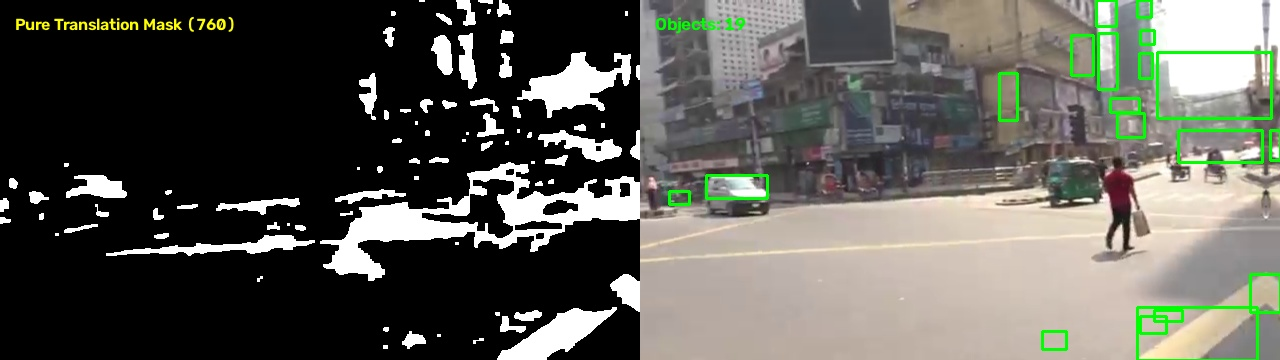

Stream stopped manually.


In [21]:
# ==============================================================================
# HYBRID PIPELINE - PURE TRANSLATION STABILIZATION (NO WARPING POSSIBLE)
# ==============================================================================

HYBRID_CONFIG = {
    "history": 200,
    "varThreshold": 28,
    "shadow_thresh": 250,
    "median_kernel": 5,
    "target_size": (640, 360),
    "min_area": 120,
    "max_area": 15000,
    "min_w_h": 10,
    "max_w_h": 220,
    "aspect_ratio_range": (0.3, 3.0),
    "static_roi_height": 140,  # Top 140px for building tracking
    "max_shift": 250           # Maximum allowed camera shift in pixels
}

cap = cv2.VideoCapture(video_path_train)

backSub_stable = cv2.createBackgroundSubtractorMOG2(
    history=HYBRID_CONFIG["history"],
    varThreshold=HYBRID_CONFIG["varThreshold"],
    detectShadows=True
)

k_small = np.ones((3, 3), np.uint8)
k_med = np.ones((5, 5), np.uint8)

# Static region mask (buildings/sky)
tracking_mask = np.zeros((360, 640), dtype=np.uint8)
tracking_mask[0:HYBRID_CONFIG["static_roi_height"], :] = 255

ret, prev_frame = cap.read()
if ret:
    prev_resized = cv2.resize(prev_frame, HYBRID_CONFIG["target_size"])
    prev_gray = cv2.cvtColor(prev_resized, cv2.COLOR_BGR2GRAY)

display_handle = display.display(None, display_id=True)
frame_idx = 1

# Accumulated shift registers
smooth_dx, smooth_dy = 0.0, 0.0

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_idx += 1
        curr_resized = cv2.resize(frame, HYBRID_CONFIG["target_size"])
        curr_gray = cv2.cvtColor(curr_resized, cv2.COLOR_BGR2GRAY)
        
        # 1. Feature Tracking in Top ROI
        prev_pts = cv2.goodFeaturesToTrack(
            prev_gray, maxCorners=100, qualityLevel=0.01, minDistance=15, mask=tracking_mask
        )
        
        dx, dy = 0.0, 0.0
        if prev_pts is not None and len(prev_pts) > 5:
            curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(
                prev_gray, curr_gray, prev_pts, None
            )
            
            idx = np.where(status == 1)[0]
            if len(idx) > 5:
                # Calculate mean movement vector (dx, dy)
                movement = curr_pts[idx] - prev_pts[idx]
                dx = np.median(movement[:, 0, 0])
                dy = np.median(movement[:, 0, 1])
        
        # 2. Both DoF Limiting & EMA Smoothing
        # Clamp shift to prevent drastic jumping
        dx = np.clip(dx, -HYBRID_CONFIG["max_shift"], HYBRID_CONFIG["max_shift"])
        dy = np.clip(dy, -HYBRID_CONFIG["max_shift"], HYBRID_CONFIG["max_shift"])
        
        # Exponential Moving Average with Damping Decay (returns to center)
        smooth_dx = 0.8 * smooth_dx + 0.2 * dx
        smooth_dy = 0.8 * smooth_dy + 0.2 * dy
        
        # 3. Apply Pure 2D Translation Matrix (Zero Rotation/Scale)
        trans_matrix = np.float32([[1, 0, -smooth_dx], [0, 1, -smooth_dy]])
        
        stabilized_frame = cv2.warpAffine(
            curr_resized,
            trans_matrix,
            HYBRID_CONFIG["target_size"],
            borderMode=cv2.BORDER_REFLECT
        )
        
        # Update reference
        prev_gray = curr_gray.copy()
        
        # 4. Background Subtraction & Detection
        fg_mask = backSub_stable.apply(stabilized_frame)
        _, binary = cv2.threshold(fg_mask, HYBRID_CONFIG["shadow_thresh"], 255, cv2.THRESH_BINARY)
        
        median = cv2.medianBlur(binary, HYBRID_CONFIG["median_kernel"])
        clean = cv2.morphologyEx(median, cv2.MORPH_OPEN, k_small)
        clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_med)
        
        contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        display_frame = stabilized_frame.copy()
        count = 0
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            x, y, w, h = cv2.boundingRect(cnt)
            ar = float(w) / h if h > 0 else 0
            
            if (HYBRID_CONFIG["min_area"] <= area <= HYBRID_CONFIG["max_area"]) and \
               (HYBRID_CONFIG["min_w_h"] <= w <= HYBRID_CONFIG["max_w_h"]) and \
               (HYBRID_CONFIG["min_w_h"] <= h <= HYBRID_CONFIG["max_w_h"]):
                if HYBRID_CONFIG["aspect_ratio_range"][0] <= ar <= HYBRID_CONFIG["aspect_ratio_range"][1]:
                    count += 1
                    cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Render Stream
        mask_bgr = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)
        cv2.putText(mask_bgr, f"Pure Translation Mask ({frame_idx})", (15, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 2)
        cv2.putText(display_frame, f"Objects: {count}", (15, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        combined_view = np.hstack((mask_bgr, display_frame))
        _, encoded_img = cv2.imencode('.jpg', combined_view)
        display_handle.update(display.Image(data=encoded_img.tobytes()))

except KeyboardInterrupt:
    print("Stream stopped manually.")

cap.release()

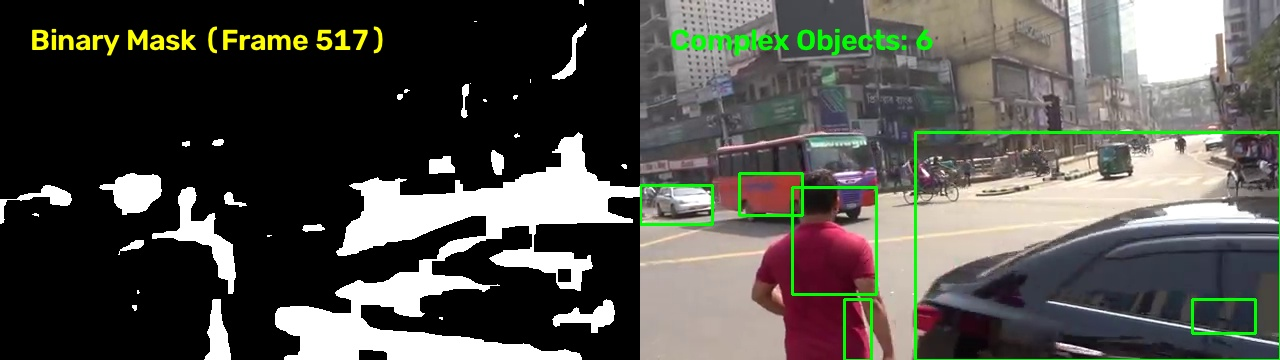

Streaming Complex Pipeline (Full Video): Left = Motion Mask | Right = Detections
Stream stopped manually.
Complex tuning preview complete.


In [12]:
# ==============================================================================
# COMPLEX PIPELINE - TUNING & LIVE MASK INSPECTION (FULL VIDEO)
# ==============================================================================

# --- TUNABLE PARAMETERS ---
COMPLEX_CONFIG = {
    "history": 200,          # Shorter memory window for responsive backgrounding
    "varThreshold": 50,      # Spatial noise cut-off
    "shadow_thresh": 200,    # Shadow suppression boundary
    "median_kernel": 9,      # Heavy non-linear median filter
    "close_iterations": 2,  # Morphological closing passes
    "min_area": 500,         # Native resolution minimum area
    "max_area": 50000        # Native resolution maximum area
}

# --- INITIALIZE PIPELINE ---
cap = cv2.VideoCapture(video_path_train)
backSub_complex = cv2.createBackgroundSubtractorMOG2(
    history=COMPLEX_CONFIG["history"],
    varThreshold=COMPLEX_CONFIG["varThreshold"],
    detectShadows=True
)

k_large = np.ones((7, 7), np.uint8)

display_handle_complex = display.display(None, display_id=True)
frame_idx = 0

print("Streaming Complex Pipeline (Full Video): Left = Motion Mask | Right = Detections")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Reached end of training video stream.")
            break
            
        frame_idx += 1
        
        # 1. Native Resolution Background Subtraction
        fg_mask = backSub_complex.apply(frame)
        _, binary = cv2.threshold(fg_mask, COMPLEX_CONFIG["shadow_thresh"], 255, cv2.THRESH_BINARY)
        
        # 2. Heavy Morphological Filtering
        median = cv2.medianBlur(binary, COMPLEX_CONFIG["median_kernel"])
        clean = cv2.morphologyEx(median, cv2.MORPH_CLOSE, k_large, iterations=COMPLEX_CONFIG["close_iterations"])
        
        # 3. Contour Detection
        contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        display_frame = frame.copy()
        count = 0
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if COMPLEX_CONFIG["min_area"] <= area <= COMPLEX_CONFIG["max_area"]:
                count += 1
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # 4. Prepare Stacking Views
        mask_bgr = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)
        
        cv2.putText(mask_bgr, f"Binary Mask (Frame {frame_idx})", (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
        cv2.putText(display_frame, f"Complex Objects: {count}", (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
        
        combined_view = np.hstack((mask_bgr, display_frame))
        
        # Downscale side-by-side output view to fit notebook width comfortably
        preview_scaled = cv2.resize(
            combined_view, 
            (1280, int(1280 * combined_view.shape[0] / combined_view.shape[1]))
        )
        
        # 5. Render Stream
        _, encoded_img = cv2.imencode('.jpg', preview_scaled)
        display_handle_complex.update(display.Image(data=encoded_img.tobytes()))

except KeyboardInterrupt:
    print("Stream stopped manually.")

cap.release()
print("Complex tuning preview complete.")

In [ ]:
# ==============================================================================
# BATCH EXECUTION & BENCHMARKING (TRAIN & TEST DATASETS)
# ==============================================================================

# 1. Run Tuned Hybrid Pipeline on Train Video
print("Running Hybrid Pipeline on Training Dataset...")
df_train_hybrid = run_pipeline(
    video_path_train,
    r"C:\Users\PC-LAB1\img_processing_lab\output\dhaka_hybrid.mp4",
    strategy="hybrid",
    config=HYBRID_CONFIG,
)

# 2. Run Tuned Complex Pipeline on Train Video
print("Running Complex Pipeline on Training Dataset...")
df_train_complex = run_pipeline(
    video_path_train,
    r"C:\Users\PC-LAB1\img_processing_lab\output\dhaka_complex.mp4",
    strategy="complex",
    config=COMPLEX_CONFIG,
)

# 3. Generalization Testing on Unseen Highway Test Video
print("Testing Generalization on British Highway Video...")
df_test_hybrid = run_pipeline(
    video_path_test,
    r"C:\Users\PC-LAB1\img_processing_lab\output\highway_hybrid.mp4",
    strategy="hybrid",
    config=HYBRID_CONFIG,
)

df_test_complex = run_pipeline(
    video_path_test,
    r"C:\Users\PC-LAB1\img_processing_lab\output\highway_complex.mp4",
    strategy="complex",
    config=COMPLEX_CONFIG,
)